# 13 딥러닝을 위해 데이터 윈도잉하고 베이스라인 모델 만들기

데이터 윈도우를 생성하는 재사용 가능한 클래스.
- 적절한 시간 윈도우를 만들고 입력과 레이블 지정. 
- 이 작업 완료 후, 다른 모델을 구현하는 것이 쉬워지고, 이 프레임워크를 다른 상황과 데이터 집합에 재사용할 수 있음.



# 13.1 데이터 윈도우 만들기

딥러닝 모델에 공급할 데이터를 적절한 형식으로 만들 수 있는 DataWindow class 만들기. 더해 도식화 method를 추가해 예측값과 실젯값 시각화.  

## 13.1.1 시계열 예측을 위한 딥러닝 모델을 훈련하는 방법 살펴보기

딥러닝은 SARIMAX와 같이 사전 정의된 함수 집합이 없음. 대신, 신경망이 입력을 받을 때 가능하면 최상의 예측을 생성할 수 있는 자체 함수를 도출하도록.  
데이터 윈도잉 (Data Windowing):
- 시계열에서 일련의 데이터 요소를 정의하고, 어떤 것이 입력이고 어떤 것이 레이블인지 정의하는 절차.
- 이러면 딥러닝 모델이 입력에 맞춰 예측을 생성하고, 레이블과 비교하고, 예측의 정확도를 개선할 수 없을 때 까지 이 과정을 반복하도록 할 수 있음. 

예시:
- 우리 데이터 윈도우는 24시간의 데이터를 사용해 다음 24시간을 예측. 
- 그런데 왜 24시간의 데이터만 사용해 예측을 생성하는가?
    - 단일 윈도우에는 24개의 시간 단계가 입력되어 24개의 시간 단계의 출력을 생성. 
    - 하지만 전체 훈련 집합은 여러 개의 윈도우로 분리되어 있어 입력값과 레이블을 포함하는 윈도우가 많음.



In [1]:
import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

from tensorflow.keras.layers import Dense, Conv1D, LSTM, Lambda, Reshape, RNN, LSTMCell

In [4]:
print(tf.__version__)

2.21.0


In [5]:
train_df = pd.read_csv('train.csv', index_col=0)
val_df = pd.read_csv('val.csv', index_col=0)
test_df = pd.read_csv('test.csv', index_col=0)

print(train_df.shape, val_df.shape, test_df.shape)

(12285, 5) (3510, 5) (1756, 5)


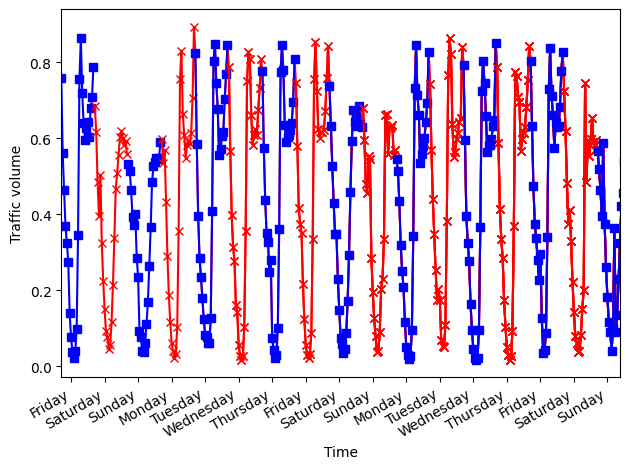

In [6]:
fig, ax = plt.subplots()

for n in range(0,17,2):
    start = 24*n
    stop = 24*(n+1)
    ax.plot(train_df.traffic_volume[start:stop], marker='s', color='blue', label='input')
    ax.plot(train_df.traffic_volume[stop:2*stop], marker='x', color='red', label='label')
ax.set_xlabel('Time')
ax.set_ylabel('Traffic volume')

plt.xticks(np.arange(7, 400, 24), ['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

그림: train 중 첫 400개의 시간 단계.  
각 데이터 윈도우: 24개의 시간 단계로 된 입력값과 24개의 시간 단계로 된 레이블 --> 총 48개의 시간 단계.

데이터 윈도우의 총 길이: 각 배열의 길이를 합한 값. 이 경우 24개의 시간 단계만큼의 입력값과 24개의 시간 단계만큼의 레이블이 있으므로 데이터 윈도우의 총 길이는 48개의 시간 단계.

![alt text](Screenshots/13.2.png)